# 🚦 ASTRAM CongestionIQ — ML Pipeline

Ten models trained on 8,173 real Bengaluru traffic incidents:

| # | Model | Task | Algorithm |
|---|-------|------|-----------|
| 1 | Incident Volume Forecaster | Regression | LightGBM |
| 2 | Road Closure Predictor | Binary Classification | RandomForest + SMOTE |
| 3 | Resource Deployment Estimator | Multi-output Regression | GradientBoosting |
| 4 | Hotspot Risk Predictor ⭐ | Regression | LightGBM |
| 5 | Incident Duration Predictor | Classification | LightGBM |
| 6 | Event Impact Score | Regression | LightGBM |
| 7 | Congestion Cascade Predictor | Markov Chain | Statistical |
| 8 | Parking Overflow Predictor | Binary Classification | Logistic Regression / GBM |
| 9 | Green Corridor Pathfinder | Graph Pathfinding | Dijkstra |
| 10 | Scenario Perturbation Engine | Rule-based | What-If Studio |

Followed by a unified **AI Advisor** that chains all models and calls Claude for NL advice.

## 0 · Setup & Imports

In [31]:
import warnings, json, os
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    classification_report, roc_auc_score, ConfusionMatrixDisplay
)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingRegressor

from imblearn.over_sampling import SMOTE
import lightgbm as lgb

sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

import glob

def _find_data_file():
    """Locate the ASTRAM event CSV without relying on a hardcoded
    machine-specific path. Looks for known filenames first, then
    falls back to any CSV file sitting next to this notebook."""
    candidates = [
        "Astram event data_anonymized - Astram event data_anonymizedb40ac87.csv",
        "Astram_event_data_anonymized_-_Astram_event_data_anonymizedb40ac87.csv",
    ]
    for c in candidates:
        if os.path.exists(c):
            return c
    csvs = glob.glob("*.csv")
    if csvs:
        return csvs[0]
    raise FileNotFoundError(
        "Could not find the ASTRAM event data CSV. Place the CSV file in the "
        "same folder as this notebook, or set DATA_PATH manually below."
    )

DATA_PATH = _find_data_file()
print('✅ All imports OK')

✅ All imports OK


## 1 · Load & Clean Data

In [32]:
df_raw = pd.read_csv(DATA_PATH)
print(f'Raw shape: {df_raw.shape}')
df_raw.head(3)

Raw shape: (8173, 46)


,id,event_type,latitude,longitude,endlatitude,endlongitude,address,end_address,event_cause,requires_road_closure,...,resolved_at_address,resolved_at_latitude,resolved_at_longitude,closed_by_id,closed_datetime,resolved_by_id,resolved_datetime,gba_identifier,zone,junction
0,FKID000000,unplanned,13.040004,77.518099,0.0,0.0,"Mumbai Bengaluru Highway, Jalahalli Cross Junc...",NaN,vehicle_breakdown,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,FKID000001,unplanned,12.921876,77.645158,0.0,0.0,"19th Main Road, Heavie Halcyon, Agara, HSR Lay...",NaN,vehicle_breakdown,False,...,"19th Main Road, Heavie Halcyon, Agara, HSR Lay...",12.921876,77.645158,NaN,NaN,FKUSR00002,2024-01-30 04:17:46.828355+00,NaN,NaN,NaN
2,FKID000002,unplanned,12.955622,77.585708,0.0,0.0,"Lalbagh Main Road, Dr Sri Shantaveera Swami Ci...",NaN,others,False,...,NaN,NaN,NaN,FKUSR00003,2024-01-30 04:56:03.281509+00,NaN,NaN,Bengaluru Central Corporation,Central Zone 2,UrvashiJunction


In [33]:
df = df_raw.copy()

# ── Parse timestamps ─────────────────────────────────────────────────────────
df['start_dt'] = pd.to_datetime(df['start_datetime'], utc=True, errors='coerce')
df['end_dt']   = pd.to_datetime(df['closed_datetime'], utc=True, errors='coerce')

# ── Time features ─────────────────────────────────────────────────────────────
df['hour']    = df['start_dt'].dt.hour.fillna(12).astype(int)
df['weekday'] = df['start_dt'].dt.dayofweek.fillna(0).astype(int)
df['month']   = df['start_dt'].dt.month.fillna(6).astype(int)
df['date']    = df['start_dt'].dt.date

# ── Duration in minutes ───────────────────────────────────────────────────────
df['duration_min'] = (df['end_dt'] - df['start_dt']).dt.total_seconds() / 60
dur_med = df['duration_min'].clip(lower=0).median()
df['duration_min'] = df['duration_min'].clip(lower=0).fillna(dur_med)

# ── Fill categoricals (keep consistent 'Unknown' sentinel) ────────────────────
for col in ['event_type', 'zone', 'corridor', 'priority', 'junction']:
    df[col] = df[col].fillna('Unknown')

# ── Binary closure flag ───────────────────────────────────────────────────────
df['closure'] = df['requires_road_closure'].astype(int)

print(f'Cleaned shape  : {df.shape}')
print(f'Date range     : {df["start_dt"].min().date()} → {df["start_dt"].max().date()}')
print(f'Closure rate   : {df["closure"].mean():.1%}')
df[['hour','weekday','month','duration_min','closure']].describe().round(2)

Cleaned shape  : (8173, 54)
Date range     : 2023-11-09 → 2024-04-08
Closure rate   : 8.3%


,hour,weekday,month,duration_min,closure
count,8173.00,8173.00,8173.00,8173.00,8173.00
mean,11.47,2.97,5.47,2471.92,0.08
std,8.18,1.91,4.46,13064.18,0.28
min,0.00,0.00,1.00,0.00,0.00
25%,4.00,1.00,2.00,64.50,0.00
50%,8.00,3.00,3.00,64.50,0.00
75%,20.00,5.00,11.00,64.50,0.00
max,23.00,6.00,12.00,201789.49,1.00


## 2 · Fit Global Label Encoders
Encoders are fitted **once on the full dataset** so every downstream model sees the same vocabulary — no unseen-label errors at inference.

In [34]:
CAT_COLS = ['event_type', 'zone', 'corridor', 'priority', 'junction']
encoders = {}

for col in CAT_COLS:
    le = LabelEncoder()
    le.fit(df[col].astype(str))
    encoders[col] = le
    df[col + '_enc'] = le.transform(df[col].astype(str))

def encode_value(value, col):
    """Encode a single value at inference time; falls back gracefully."""
    le = encoders[col]
    val = str(value)
    if val not in le.classes_:
        val = 'Unknown' if 'Unknown' in le.classes_ else le.classes_[0]
    return int(le.transform([val])[0])

print('✅ Encoders fitted for:', list(encoders.keys()))

✅ Encoders fitted for: ['event_type', 'zone', 'corridor', 'priority', 'junction']


## 3 · Exploratory Data Analysis

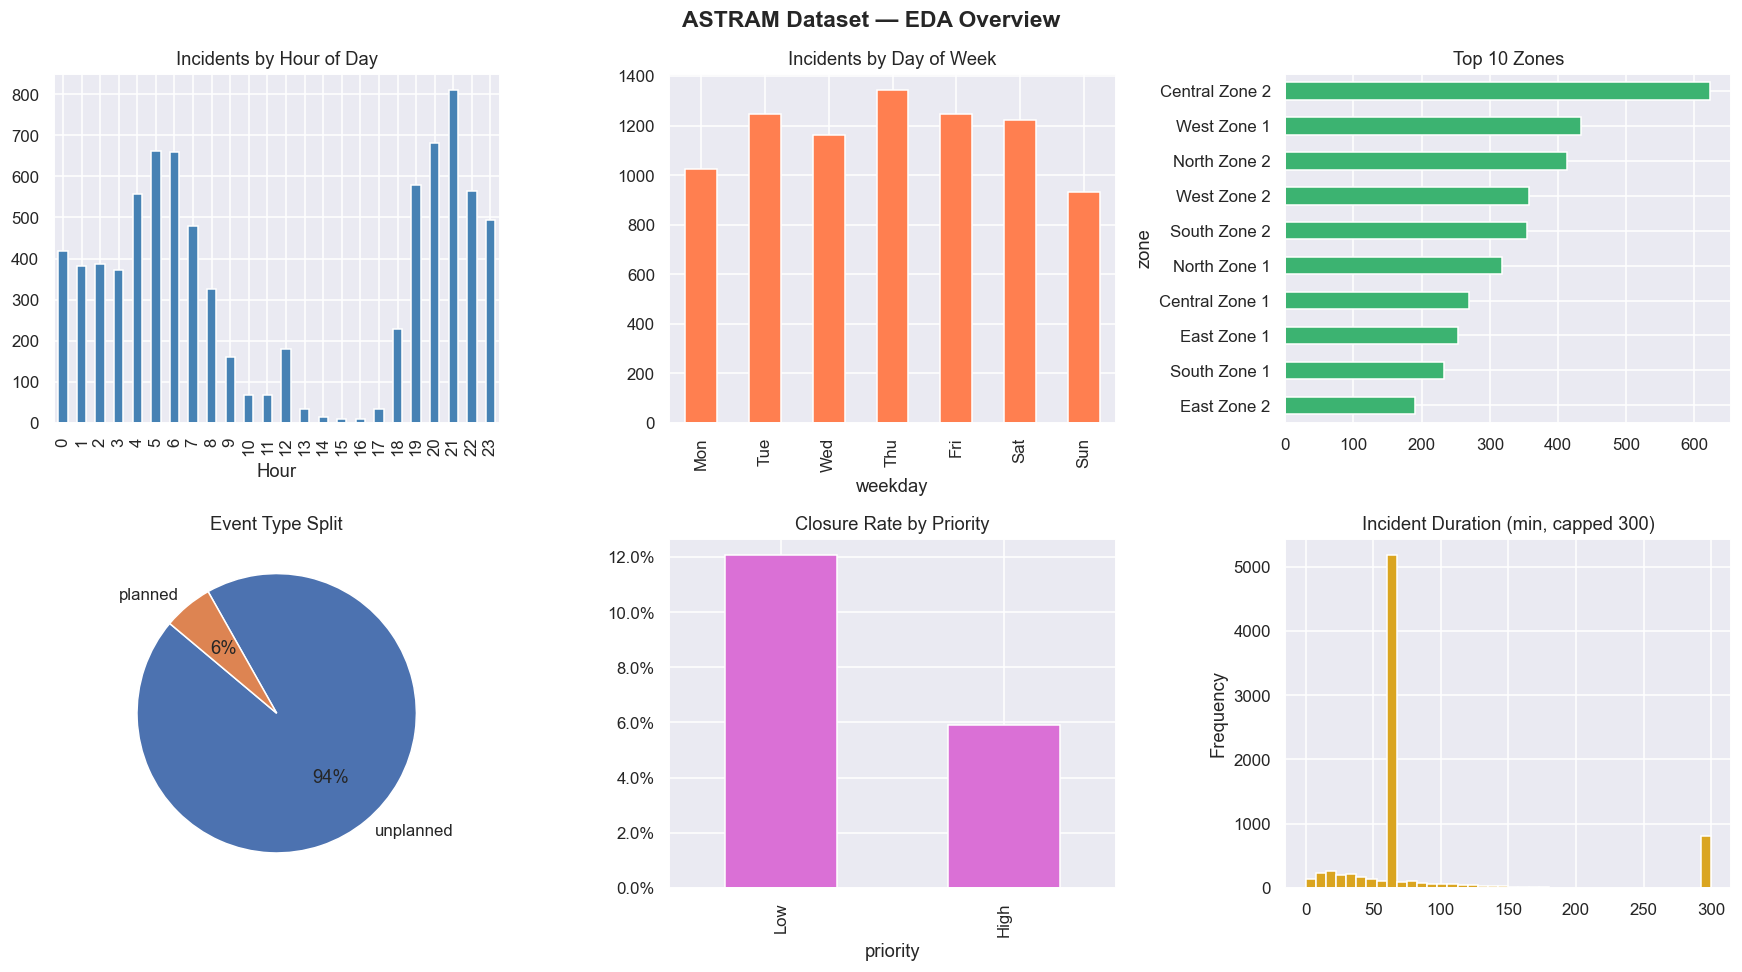

In [35]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('ASTRAM Dataset — EDA Overview', fontsize=15, fontweight='bold')

# 1. Incidents by hour
df['hour'].value_counts().sort_index().plot(kind='bar', ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Incidents by Hour of Day'); axes[0,0].set_xlabel('Hour')

# 2. Incidents by weekday
day_map = {0:'Mon',1:'Tue',2:'Wed',3:'Thu',4:'Fri',5:'Sat',6:'Sun'}
df['weekday'].map(day_map).value_counts().reindex(day_map.values()).plot(
    kind='bar', ax=axes[0,1], color='coral')
axes[0,1].set_title('Incidents by Day of Week')

# 3. Top zones (excluding Unknown)
df[df['zone']!='Unknown']['zone'].value_counts().head(10).plot(
    kind='barh', ax=axes[0,2], color='mediumseagreen')
axes[0,2].set_title('Top 10 Zones'); axes[0,2].invert_yaxis()

# 4. Event type pie
df['event_type'].value_counts().plot(kind='pie', ax=axes[1,0], autopct='%1.0f%%',
    colors=['#4C72B0','#DD8452'], startangle=140)
axes[1,0].set_ylabel(''); axes[1,0].set_title('Event Type Split')

# 5. Closure rate by priority
clos = df[df['priority']!='Unknown'].groupby('priority')['closure'].mean().sort_values(ascending=False)
clos.plot(kind='bar', ax=axes[1,1], color='orchid')
axes[1,1].set_title('Closure Rate by Priority')
axes[1,1].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

# 6. Duration distribution
df['duration_min'].clip(upper=300).plot(kind='hist', bins=40, ax=axes[1,2], color='goldenrod')
axes[1,2].set_title('Incident Duration (min, capped 300)')

plt.tight_layout()
plt.show()

### Correlation Heatmap

Let's visualize the correlation between the numerical and encoded categorical features, including the `closure` flag, to understand their relationships.

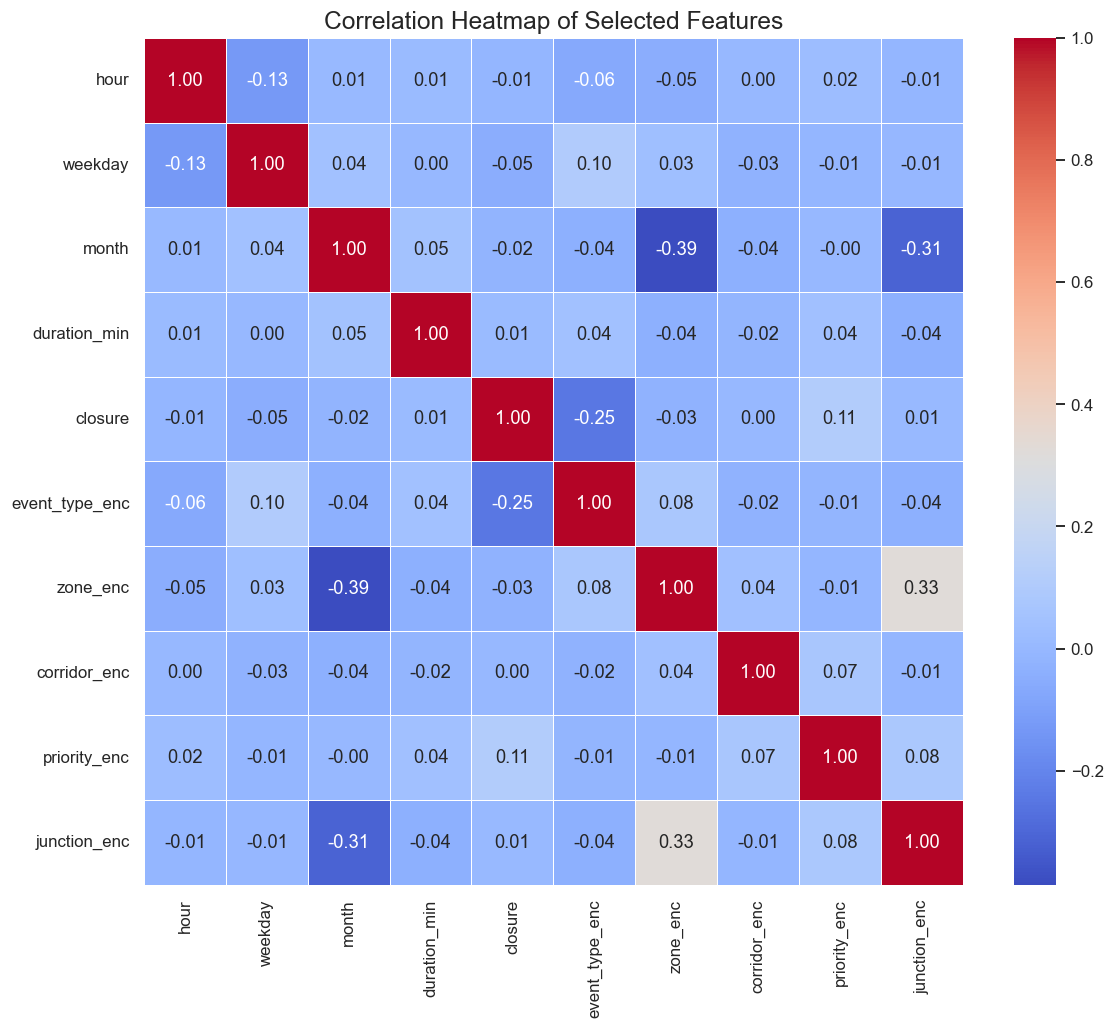

In [36]:
numeric_and_encoded_cols = [
    'hour', 'weekday', 'month', 'duration_min', 'closure',
    'event_type_enc', 'zone_enc', 'corridor_enc', 'priority_enc', 'junction_enc'
]

# Ensure all columns exist before selecting
selected_cols = [col for col in numeric_and_encoded_cols if col in df.columns]

corr_matrix = df[selected_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Selected Features', fontsize=16)
plt.show()

---
## Model 1 — Incident Volume Forecaster
> **Goal:** Predict how many incidents will occur for a given (zone, corridor, event_type, hour, weekday, month) bucket.
>
> **Algorithm:** LightGBM Regressor

In [37]:
# ── Aggregate to incident counts ──────────────────────────────────────────────
forecast_df = (
    df.groupby(['zone','corridor','event_type','hour','weekday','month'])
    .size()
    .reset_index(name='incident_count')
)
forecast_df['zone_enc']     = encoders['zone'].transform(forecast_df['zone'].astype(str))
forecast_df['corridor_enc'] = encoders['corridor'].transform(forecast_df['corridor'].astype(str))
forecast_df['etype_enc']    = encoders['event_type'].transform(forecast_df['event_type'].astype(str))

print(f'Forecast rows: {len(forecast_df)}')
forecast_df['incident_count'].describe().round(2)

Forecast rows: 5201


count    5201.00
mean        1.57
std         1.86
min         1.00
25%         1.00
50%         1.00
75%         2.00
max        55.00
Name: incident_count, dtype: float64

In [38]:
FEAT_1 = ['zone_enc','corridor_enc','etype_enc','hour','weekday','month']
X1 = forecast_df[FEAT_1]
y1 = forecast_df['incident_count']

X1_tr, X1_te, y1_tr, y1_te = train_test_split(X1, y1, test_size=0.2, random_state=42)

model1 = lgb.LGBMRegressor(
    n_estimators=400, learning_rate=0.05, max_depth=6, num_leaves=31,
    subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, verbose=-1
)
model1.fit(X1_tr, y1_tr,
           eval_set=[(X1_te, y1_te)],
           callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(-1)])

y1_pred = model1.predict(X1_te)
r2_1  = r2_score(y1_te, y1_pred)
mae1  = mean_absolute_error(y1_te, y1_pred)
rmse1 = np.sqrt(mean_squared_error(y1_te, y1_pred))

print(f'MAE : {mae1:.3f}  |  RMSE : {rmse1:.3f}  |  R² : {r2_1:.3f}')

MAE : 0.712  |  RMSE : 1.488  |  R² : 0.368


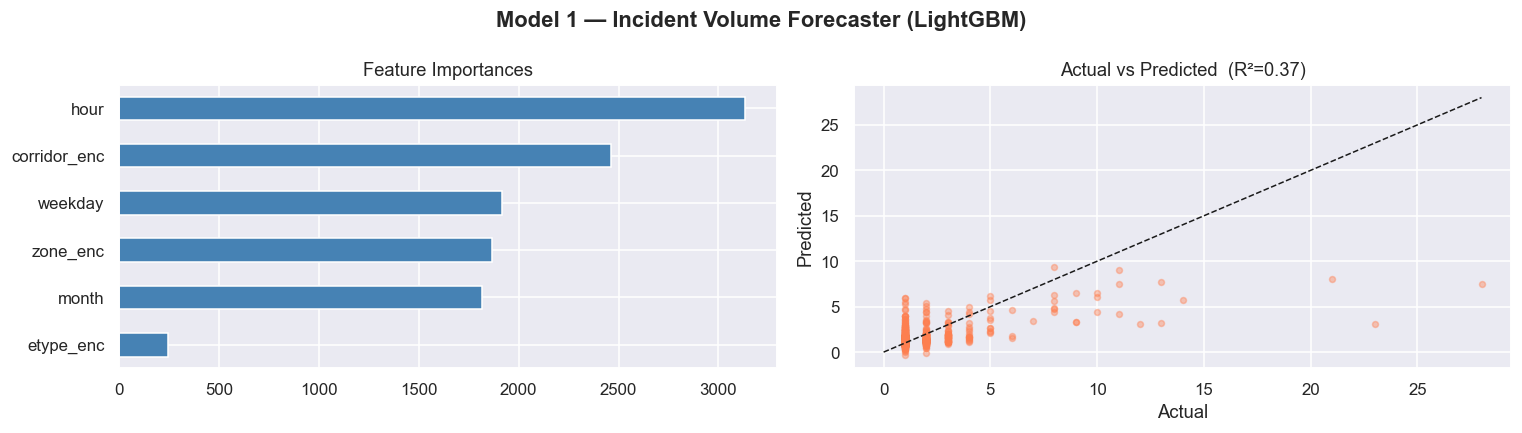

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Model 1 — Incident Volume Forecaster (LightGBM)', fontweight='bold')

imp1 = pd.Series(model1.feature_importances_, index=FEAT_1).sort_values()
imp1.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Feature Importances')

axes[1].scatter(y1_te, y1_pred, alpha=0.4, s=15, color='coral')
mx = max(y1_te.max(), y1_pred.max())
axes[1].plot([0, mx], [0, mx], 'k--', lw=1)
axes[1].set_xlabel('Actual'); axes[1].set_ylabel('Predicted')
axes[1].set_title(f'Actual vs Predicted  (R²={r2_1:.2f})')

plt.tight_layout(); plt.show()

In [40]:
def predict_incident_volume(zone, corridor, event_type, hour, weekday, month):
    row = pd.DataFrame([{
        'zone_enc'    : encode_value(zone,       'zone'),
        'corridor_enc': encode_value(corridor,   'corridor'),
        'etype_enc'   : encode_value(event_type, 'event_type'),
        'hour': hour, 'weekday': weekday, 'month': month,
    }])
    return max(0, round(float(model1.predict(row)[0])))

demo1 = predict_incident_volume('Central Zone 2', 'CBD 2', 'unplanned', 21, 4, 6)
print(f'Expected incidents next hour → {demo1}')

Expected incidents next hour → 1


---
## Model 2 — Road Closure Predictor
> **Goal:** Predict whether an incident will require road closure.
>
> **Algorithm:** SMOTE → RandomForestClassifier

In [41]:
FEAT_2 = ['event_type_enc','zone_enc','corridor_enc','priority_enc','hour','duration_min']
X2 = df[FEAT_2]
y2 = df['closure']

print(f'Class balance — 0: {(y2==0).sum()}  |  1: {(y2==1).sum()}  |  minority: {y2.mean():.1%}')

X2_tr, X2_te, y2_tr, y2_te = train_test_split(X2, y2, test_size=0.2, stratify=y2, random_state=42)

smote = SMOTE(random_state=42, k_neighbors=5)
X2_res, y2_res = smote.fit_resample(X2_tr, y2_tr)
print(f'After SMOTE — 0: {(y2_res==0).sum()}  |  1: {(y2_res==1).sum()}')

Class balance — 0: 7497  |  1: 676  |  minority: 8.3%
After SMOTE — 0: 5997  |  1: 5997


In [42]:
model2 = RandomForestClassifier(
    n_estimators=300, max_depth=10, class_weight='balanced',
    random_state=42, n_jobs=-1
)
model2.fit(X2_res, y2_res)

y2_pred  = model2.predict(X2_te)
y2_proba = model2.predict_proba(X2_te)[:, 1]
auc2     = roc_auc_score(y2_te, y2_proba)

print(classification_report(y2_te, y2_pred, target_names=['No Closure','Closure']))
print(f'ROC-AUC: {auc2:.3f}')

              precision    recall  f1-score   support

  No Closure       0.95      0.82      0.88      1500
     Closure       0.20      0.48      0.28       135

    accuracy                           0.80      1635
   macro avg       0.57      0.65      0.58      1635
weighted avg       0.88      0.80      0.83      1635

ROC-AUC: 0.690


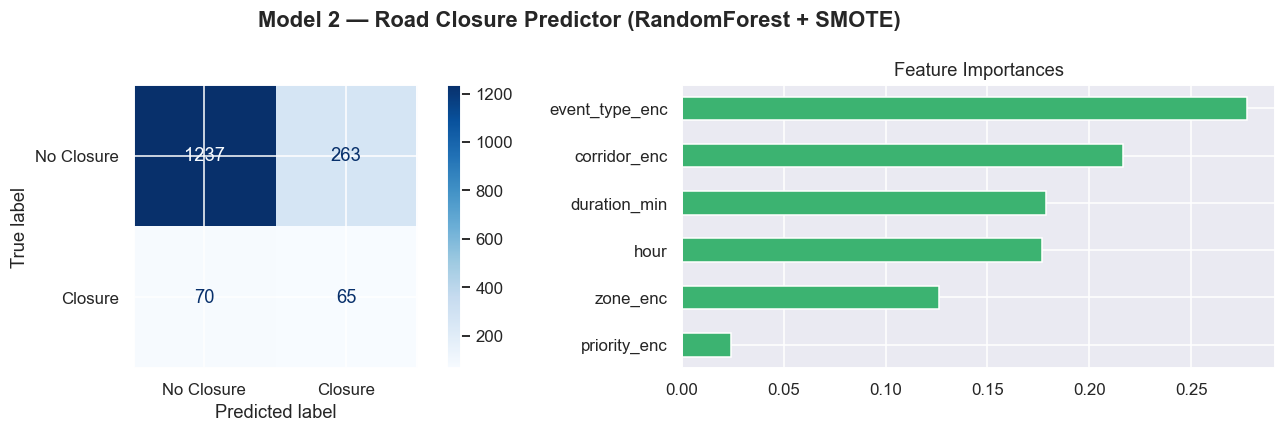

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Model 2 — Road Closure Predictor (RandomForest + SMOTE)', fontweight='bold')

ConfusionMatrixDisplay.from_predictions(y2_te, y2_pred,
    display_labels=['No Closure','Closure'], cmap='Blues', ax=axes[0])

pd.Series(model2.feature_importances_, index=FEAT_2).sort_values().plot(
    kind='barh', ax=axes[1], color='mediumseagreen')
axes[1].set_title('Feature Importances')

plt.tight_layout(); plt.show()

In [44]:
def predict_closure(event_type, zone, corridor, priority, hour, duration_min):
    row = pd.DataFrame([{
        'event_type_enc': encode_value(event_type, 'event_type'),
        'zone_enc'      : encode_value(zone,       'zone'),
        'corridor_enc'  : encode_value(corridor,   'corridor'),
        'priority_enc'  : encode_value(priority,   'priority'),
        'hour'          : hour,
        'duration_min'  : duration_min,
    }])
    return round(float(model2.predict_proba(row)[0, 1]) * 100, 1)

demo2 = predict_closure('unplanned', 'Central Zone 2', 'CBD 2', 'High', 21, 45)
print(f'Closure Probability → {demo2}%')

Closure Probability → 39.6%


---
## Model 3 — Resource Deployment Estimator
> **Goal:** Predict officers and barricades needed.
>
> **Algorithm:** GradientBoostingRegressor (two independent regressors)
>
> Synthetic labels based on operational playbook rules.

In [45]:
rng = np.random.default_rng(42)
OFFICER_MAP  = {'planned': 20, 'unplanned': 8, 'Unknown': 5}
PRIORITY_MULT = {'High': 1.5, 'Low': 1.0, 'Unknown': 1.0}
BARRICADE_MAP = {'planned': 15, 'unplanned': 5, 'Unknown': 3}

df['officers_needed'] = (
    df['event_type'].map(OFFICER_MAP).fillna(5)
    * df['priority'].map(PRIORITY_MULT).fillna(1.0)
    + df['closure'] * 6
    + rng.integers(-2, 3, size=len(df))
).clip(lower=1).round()

df['barricades_needed'] = (
    df['event_type'].map(BARRICADE_MAP).fillna(3)
    * df['priority'].map(PRIORITY_MULT).fillna(1.0)
    + df['closure'] * 10
    + rng.integers(-3, 4, size=len(df))
).clip(lower=0).round()

print(df[['officers_needed','barricades_needed']].describe().round(2))

       officers_needed  barricades_needed
count          8173.00            8173.00
mean             11.82               8.06
std               4.96               5.10
min               6.00               2.00
25%               9.00               5.00
50%              11.00               7.00
75%              13.00              10.00
max              38.00              36.00


In [46]:
FEAT_3 = ['event_type_enc','priority_enc','zone_enc','corridor_enc','hour'] # Removed 'closure' from features
X3 = df[FEAT_3]

X3_tr, X3_te = train_test_split(X3, test_size=0.2, random_state=42)
y3_off_tr  = df.loc[X3_tr.index, 'officers_needed']
y3_bar_tr  = df.loc[X3_tr.index, 'barricades_needed']
y3_off_te  = df.loc[X3_te.index, 'officers_needed']
y3_bar_te  = df.loc[X3_te.index, 'barricades_needed']

gb_params = dict(n_estimators=200, learning_rate=0.05, max_depth=4, random_state=42)
officer_model   = GradientBoostingRegressor(**gb_params)
barricade_model = GradientBoostingRegressor(**gb_params)
officer_model.fit(X3_tr, y3_off_tr)
barricade_model.fit(X3_tr, y3_bar_tr)

for name, m, y_te in [('Officers',   officer_model,   y3_off_te),
                       ('Barricades', barricade_model, y3_bar_te)]:
    pred = m.predict(X3_te)
    print(f'{name:12s} → MAE={mean_absolute_error(y_te,pred):.2f}  '
          f'RMSE={np.sqrt(mean_squared_error(y_te,pred)):.2f}  '
          f'R²={r2_score(y_te,pred):.3f}')

Officers     → MAE=1.59  RMSE=2.08  R²=0.818
Barricades   → MAE=2.40  RMSE=3.35  R²=0.572


### Basic Closure Prediction Model

Let's train a basic RandomForestClassifier to predict the `closure` variable using the `X3_tr` features. This will serve as a simple example of a classification model for road closure prediction.

In [47]:
y_closure_tr = df.loc[X3_tr.index, 'closure']
y_closure_te = df.loc[X3_te.index, 'closure']

basic_closure_model = RandomForestClassifier(
    n_estimators=100, max_depth=5, random_state=42, n_jobs=-1
)
basic_closure_model.fit(X3_tr, y_closure_tr)

y_closure_pred = basic_closure_model.predict(X3_te)
y_closure_proba = basic_closure_model.predict_proba(X3_te)[:, 1]

print('Classification Report for Basic Closure Model:')
print(classification_report(y_closure_te, y_closure_pred, target_names=['No Closure', 'Closure']))
print(f'ROC-AUC for Basic Closure Model: {roc_auc_score(y_closure_te, y_closure_proba):.3f}')

Classification Report for Basic Closure Model:
              precision    recall  f1-score   support

  No Closure       0.93      1.00      0.96      1498
     Closure       0.85      0.12      0.22       137

    accuracy                           0.92      1635
   macro avg       0.89      0.56      0.59      1635
weighted avg       0.92      0.92      0.90      1635

ROC-AUC for Basic Closure Model: 0.694


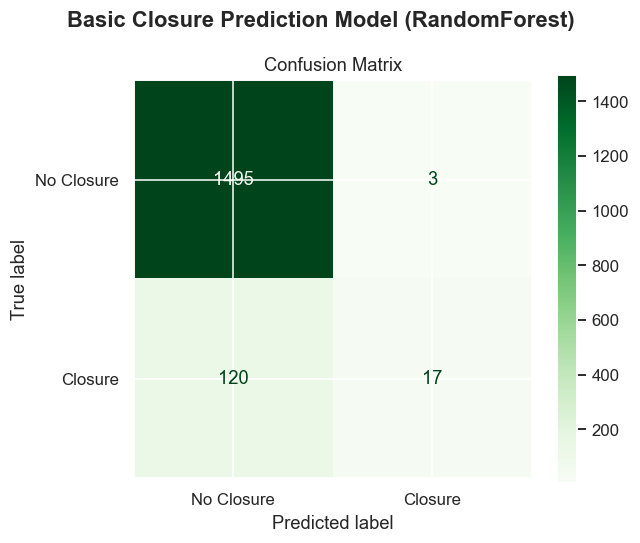

In [48]:
fig, ax = plt.subplots(figsize=(6, 5))
fig.suptitle('Basic Closure Prediction Model (RandomForest)', fontweight='bold')

ConfusionMatrixDisplay.from_predictions(y_closure_te, y_closure_pred,
    display_labels=['No Closure','Closure'], cmap='Greens', ax=ax)
plt.title('Confusion Matrix')

plt.tight_layout()
plt.show()

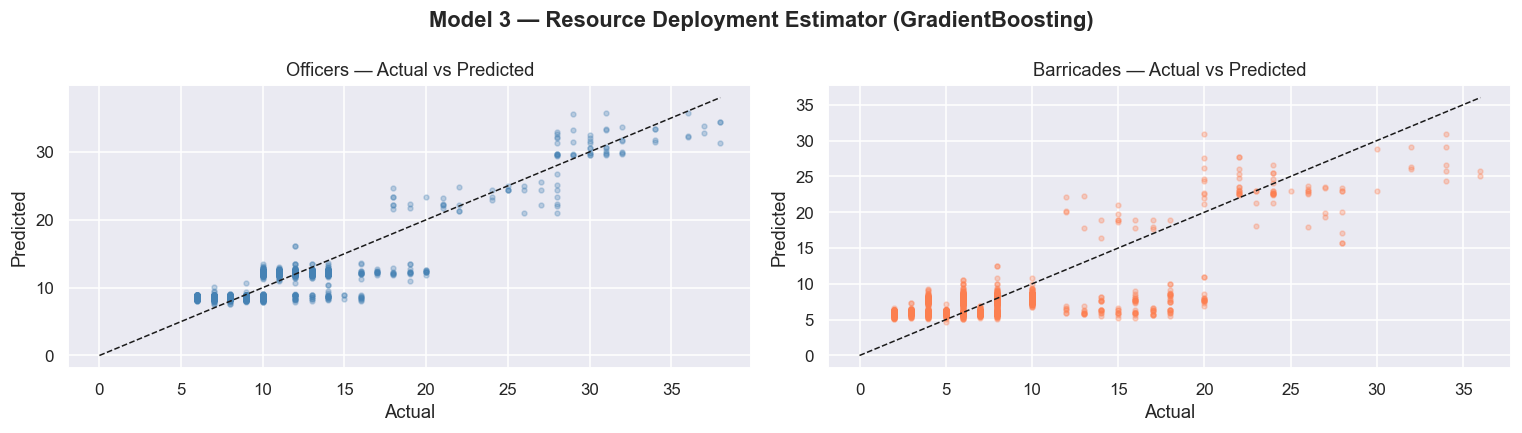

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Model 3 — Resource Deployment Estimator (GradientBoosting)', fontweight='bold')

for ax, m, y_te, label, color in [
    (axes[0], officer_model,   y3_off_te, 'Officers',   'steelblue'),
    (axes[1], barricade_model, y3_bar_te, 'Barricades', 'coral'),
]:
    pred = m.predict(X3_te)
    ax.scatter(y_te, pred, alpha=0.3, s=10, color=color)
    mx = max(y_te.max(), pred.max())
    ax.plot([0, mx], [0, mx], 'k--', lw=1)
    ax.set_title(f'{label} — Actual vs Predicted')
    ax.set_xlabel('Actual'); ax.set_ylabel('Predicted')

plt.tight_layout(); plt.show()

In [50]:
def predict_resources(event_type, priority, zone, corridor, hour, closure_prob):
    closure_flag = 1 if closure_prob >= 50 else 0
    row = pd.DataFrame([{
        'event_type_enc': encode_value(event_type, 'event_type'),
        'priority_enc'  : encode_value(priority,   'priority'),
        'zone_enc'      : encode_value(zone,        'zone'),
        'corridor_enc'  : encode_value(corridor,    'corridor'),
        'hour'          : hour,
        # 'closure'       : closure_flag, # Removed as models were trained without it
    }])
    return (
        max(1, round(float(officer_model.predict(row)[0]))),
        max(0, round(float(barricade_model.predict(row)[0])))
    )

off, bar = predict_resources('unplanned', 'High', 'Central Zone 2', 'CBD 2', 21, demo2)
print(f'Officers: {off}  |  Barricades: {bar}')

Officers: 12  |  Barricades: 8


---
## Model 4 ⭐ — Hotspot Risk Predictor
> **Goal:** Score each junction (0–100) for predicted incident risk at a given hour/weekday.
>
> **Algorithm:** LightGBM Regressor on composite risk score

In [51]:
hot = df[df['junction'] != 'Unknown'].copy()

hot_agg = (
    hot.groupby(['junction','hour','weekday','event_type'])
    .agg(
        incident_count=('id',           'count'),
        closure_rate  =('closure',      'mean'),
        avg_duration  =('duration_min', 'mean'),
    )
    .reset_index()
)

# Normalise each component 0–1 then blend
for col in ['incident_count', 'closure_rate', 'avg_duration']:
    mn, mx = hot_agg[col].min(), hot_agg[col].max()
    hot_agg[col + '_norm'] = (hot_agg[col] - mn) / (mx - mn + 1e-9)

hot_agg['risk_score'] = (
    0.60 * hot_agg['incident_count_norm'] +
    0.30 * hot_agg['closure_rate_norm']   +
    0.10 * hot_agg['avg_duration_norm']
) * 100

# Encode junction within this sub-table using the global encoder
hot_agg['junction_enc']  = encoders['junction'].transform(hot_agg['junction'].astype(str))
hot_agg['etype_enc']     = encoders['event_type'].transform(hot_agg['event_type'].astype(str))

print(f'Hotspot rows: {len(hot_agg)}')
hot_agg['risk_score'].describe().round(2)

Hotspot rows: 2112


count    2112.00
mean        3.22
std         8.48
min         0.00
25%         0.00
50%         0.00
75%         0.48
max        60.32
Name: risk_score, dtype: float64

In [52]:
FEAT_4 = ['junction_enc','hour','weekday','etype_enc']
X4 = hot_agg[FEAT_4]
y4 = hot_agg['risk_score']

X4_tr, X4_te, y4_tr, y4_te = train_test_split(X4, y4, test_size=0.2, random_state=42)

model4 = lgb.LGBMRegressor(
    n_estimators=300, learning_rate=0.05, max_depth=5,
    random_state=42, n_jobs=-1, verbose=-1
)
model4.fit(X4_tr, y4_tr,
           eval_set=[(X4_te, y4_te)],
           callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(-1)])

y4_pred = model4.predict(X4_te)
r2_4 = r2_score(y4_te, y4_pred)
print(f'MAE : {mean_absolute_error(y4_te, y4_pred):.3f}  |  R² : {r2_4:.3f}')

MAE : 4.171  |  R² : 0.125


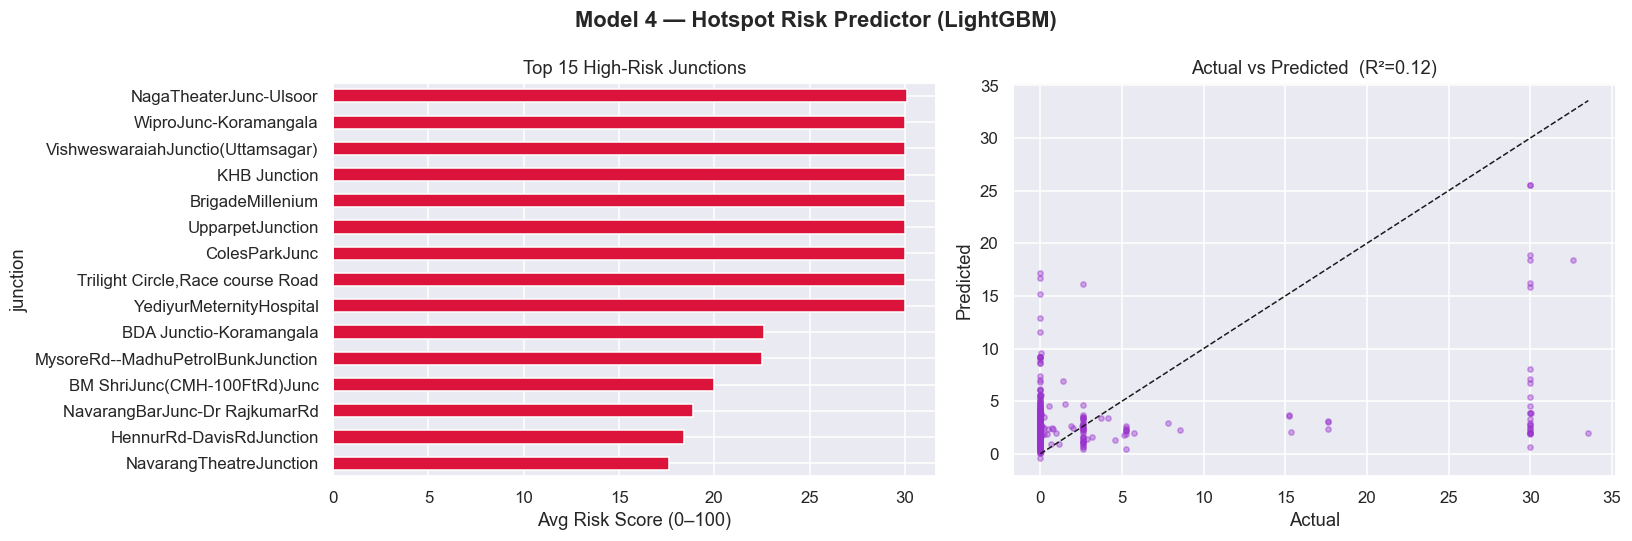


Top 10 riskiest junctions:
  NagaTheaterJunc-Ulsoor                      30.1/100  ███████████████
  WiproJunc-Koramangala                       30.0/100  ███████████████
  ColesParkJunc                               30.0/100  ███████████████
  UpparpetJunction                            30.0/100  ███████████████
  BrigadeMillenium                            30.0/100  ███████████████
  KHB Junction                                30.0/100  ███████████████
  VishweswaraiahJunctio(Uttamsagar)           30.0/100  ███████████████
  Trilight Circle,Race course Road            30.0/100  ███████████████
  YediyurMeternityHospital                    30.0/100  ███████████████
  BDA Junctio-Koramangala                     22.6/100  ███████████


In [53]:
junction_risk = (
    hot_agg.groupby('junction')['risk_score']
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Model 4 — Hotspot Risk Predictor (LightGBM)', fontweight='bold')

junction_risk.sort_values().plot(kind='barh', ax=axes[0], color='crimson')
axes[0].set_title('Top 15 High-Risk Junctions')
axes[0].set_xlabel('Avg Risk Score (0–100)')

axes[1].scatter(y4_te, y4_pred, alpha=0.4, s=12, color='darkorchid')
mx = max(y4_te.max(), y4_pred.max())
axes[1].plot([0, mx], [0, mx], 'k--', lw=1)
axes[1].set_xlabel('Actual'); axes[1].set_ylabel('Predicted')
axes[1].set_title(f'Actual vs Predicted  (R²={r2_4:.2f})')

plt.tight_layout(); plt.show()

print('\nTop 10 riskiest junctions:')
for junc, score in junction_risk.head(10).items():
    bar_len = int(score / 2)
    print(f'  {junc:<42s} {score:5.1f}/100  {"█" * bar_len}')

In [54]:
def predict_hotspot_risk(junction, hour, weekday, event_type):
    row = pd.DataFrame([{
        'junction_enc': encode_value(junction,   'junction'),
        'hour'        : hour,
        'weekday'     : weekday,
        'etype_enc'   : encode_value(event_type, 'event_type'),
    }])
    return round(float(np.clip(model4.predict(row)[0], 0, 100)), 1)

print('Junction Risk @ 21:00 Friday (unplanned):')
for j in junction_risk.head(5).index:
    score = predict_hotspot_risk(j, 21, 4, 'unplanned')
    print(f'  {j:<42s} → {score}/100')

Junction Risk @ 21:00 Friday (unplanned):
  NagaTheaterJunc-Ulsoor                     → 2.8/100
  WiproJunc-Koramangala                      → 3.4/100
  ColesParkJunc                              → 2.4/100
  UpparpetJunction                           → 2.5/100
  BrigadeMillenium                           → 3.9/100


---
## 5 · AI Advisor — Unified Pipeline
> Chain all four models, then send the prediction package to Claude for a natural-language operations brief.

In [55]:
def run_ai_advisor(zone, corridor, event_type, hour, weekday, month,
                   priority='High', duration_min=60):
    # M1 — volume
    predicted_incidents = predict_incident_volume(
        zone, corridor, event_type, hour, weekday, month)

    # M2 — closure
    closure_probability = predict_closure(
        event_type, zone, corridor, priority, hour, duration_min)

    # M3 — resources
    officers, barricades = predict_resources(
        event_type, priority, zone, corridor, hour, closure_probability)

    # M4 — top junctions in this zone
    zone_junctions = (
        df[(df['zone'] == zone) & (df['junction'] != 'Unknown')]['junction']
        .value_counts().head(5).index.tolist()
    )
    hotspots = sorted(
        [{'junction': j,
          'risk_score': predict_hotspot_risk(j, hour, weekday, event_type)}
         for j in zone_junctions],
        key=lambda x: x['risk_score'], reverse=True
    )[:3]

    return {
        'zone': zone, 'corridor': corridor,
        'event_type': event_type, 'hour': hour,
        'predicted_incidents': predicted_incidents,
        'closure_probability': closure_probability,
        'officers_needed': officers,
        'barricades_needed': barricades,
        'top_hotspots': hotspots,
    }


advisor_result = run_ai_advisor(
    zone='Central Zone 2', corridor='CBD 2',
    event_type='unplanned', hour=21, weekday=4, month=6
)

print('📊 AI Advisor — Prediction Package')
print(json.dumps(advisor_result, indent=2))

📊 AI Advisor — Prediction Package
{
  "zone": "Central Zone 2",
  "corridor": "CBD 2",
  "event_type": "unplanned",
  "hour": 21,
  "predicted_incidents": 1,
  "closure_probability": 35.6,
  "officers_needed": 12,
  "barricades_needed": 8,
  "top_hotspots": [
    {
      "junction": "K R Circle",
      "risk_score": 4.6
    },
    {
      "junction": "PoliceCornerJunc",
      "risk_score": 4.1
    },
    {
      "junction": "TownhallJunction",
      "risk_score": 3.8
    }
  ]
}


In [56]:
import urllib.request as _ureq

def generate_nl_advice(prediction: dict) -> str:
    """
    Calls Claude claude-sonnet-4-6 with the prediction dict and returns
    a natural-language operations brief.
    Set ANTHROPIC_API_KEY env var to enable live calls.
    """
    hotspot_text = ', '.join(
        f"{h['junction']} ({h['risk_score']:.0f}/100)"
        for h in prediction['top_hotspots']
    )
    prompt = f"""You are ASTRAM CongestionIQ, a real-time traffic operations advisor for Bengaluru.

Based on the ML model predictions below, provide a brief, actionable operations brief for the
traffic control centre. Be specific about junctions, timings, and deployment.
Use bullet points for recommended actions. Keep under 120 words.

Zone                : {prediction['zone']}
Corridor            : {prediction['corridor']}
Event type          : {prediction['event_type']}
Time                : {prediction['hour']:02d}:00
Predicted incidents : {prediction['predicted_incidents']}
Road closure risk   : {prediction['closure_probability']}%
Officers needed     : {prediction['officers_needed']}
Barricades needed   : {prediction['barricades_needed']}
High-risk junctions : {hotspot_text}
"""

    api_key = os.environ.get('ANTHROPIC_API_KEY', '')
    if not api_key:
        return (
            '[ANTHROPIC_API_KEY not set — set it to enable live AI advice.\n'
            f'Prompt ready to send:\n{prompt}]'
        )

    payload = json.dumps({
        'model': 'claude-sonnet-4-6',
        'max_tokens': 300,
        'messages': [{'role': 'user', 'content': prompt}]
    }).encode()

    req = _ureq.Request(
        'https://api.anthropic.com/v1/messages',
        data=payload,
        headers={
            'Content-Type'      : 'application/json',
            'x-api-key'         : api_key,
            'anthropic-version' : '2023-06-01',
        },
        method='POST'
    )
    with _ureq.urlopen(req) as resp:
        data = json.loads(resp.read())
    return data['content'][0]['text']


advice = generate_nl_advice(advisor_result)
print('\n🤖 AI Advisor — Natural Language Brief')
print('─' * 60)
print(advice)


🤖 AI Advisor — Natural Language Brief
────────────────────────────────────────────────────────────
[ANTHROPIC_API_KEY not set — set it to enable live AI advice.
Prompt ready to send:
You are ASTRAM CongestionIQ, a real-time traffic operations advisor for Bengaluru.

Based on the ML model predictions below, provide a brief, actionable operations brief for the
traffic control centre. Be specific about junctions, timings, and deployment.
Use bullet points for recommended actions. Keep under 120 words.

Zone                : Central Zone 2
Corridor            : CBD 2
Event type          : unplanned
Time                : 21:00
Predicted incidents : 1
Road closure risk   : 35.6%
Officers needed     : 12
Barricades needed   : 8
High-risk junctions : K R Circle (5/100), PoliceCornerJunc (4/100), TownhallJunction (4/100)
]


---
## 6 · All-Models Summary Dashboard

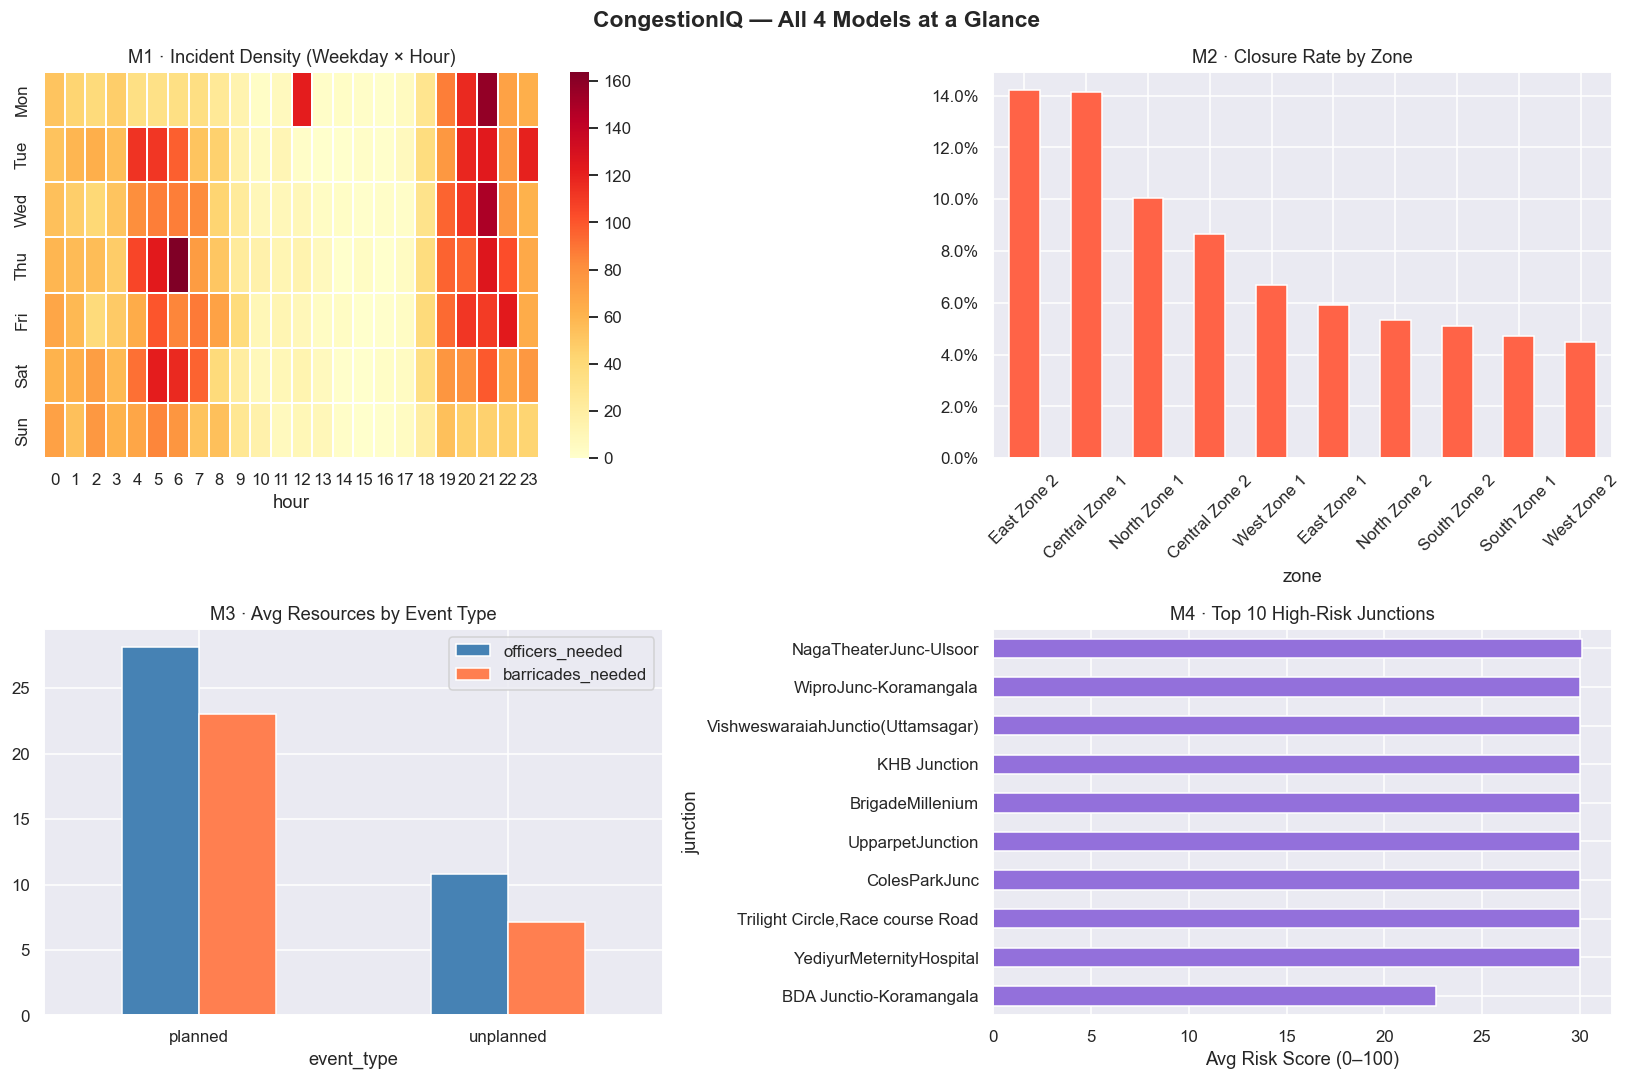


📋 Model Performance Scorecard
─────────────────────────────────────────────────────────────────
  M1 · Incident Volume Forecaster         LightGBM Regressor        R²=0.368  MAE=0.71
  M2 · Road Closure Predictor             RandomForest + SMOTE      ROC-AUC=0.690
  M3 · Resource Deployment Estimator      GradientBoosting ×2       Officers MAE=1.59
  M4 · Hotspot Risk Predictor ⭐           LightGBM Regressor        R²=0.125


In [57]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('CongestionIQ — All 4 Models at a Glance', fontsize=15, fontweight='bold')

# M1: incident heatmap
heat = df.pivot_table(index='weekday', columns='hour', values='id',
                       aggfunc='count', fill_value=0)
heat.index = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
sns.heatmap(heat, ax=axes[0,0], cmap='YlOrRd', linewidths=0.3, annot=False)
axes[0,0].set_title('M1 · Incident Density (Weekday × Hour)')

# M2: closure rate by zone
zone_cl = df[df['zone']!='Unknown'].groupby('zone')['closure'].mean().sort_values(ascending=False).head(10)
zone_cl.plot(kind='bar', ax=axes[0,1], color='tomato')
axes[0,1].set_title('M2 · Closure Rate by Zone')
axes[0,1].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[0,1].tick_params(axis='x', rotation=45)

# M3: avg resources by event type
df.groupby('event_type')[['officers_needed','barricades_needed']].mean().plot(
    kind='bar', ax=axes[1,0], color=['steelblue','coral'])
axes[1,0].set_title('M3 · Avg Resources by Event Type')
axes[1,0].tick_params(axis='x', rotation=0)

# M4: top junction risks
junction_risk.head(10).sort_values().plot(kind='barh', ax=axes[1,1], color='mediumpurple')
axes[1,1].set_title('M4 · Top 10 High-Risk Junctions')
axes[1,1].set_xlabel('Avg Risk Score (0–100)')

plt.tight_layout(); plt.show()

# Print scorecard
m3_mae_off = mean_absolute_error(y3_off_te, officer_model.predict(X3_te))
print('\n📋 Model Performance Scorecard')
print('─' * 65)
rows = [
    ('M1 · Incident Volume Forecaster',   'LightGBM Regressor',         f'R²={r2_1:.3f}  MAE={mae1:.2f}'),
    ('M2 · Road Closure Predictor',       'RandomForest + SMOTE',       f'ROC-AUC={auc2:.3f}'),
    ('M3 · Resource Deployment Estimator','GradientBoosting ×2',        f'Officers MAE={m3_mae_off:.2f}'),
    ('M4 · Hotspot Risk Predictor ⭐',    'LightGBM Regressor',         f'R²={r2_4:.3f}'),
]
for name, algo, metric in rows:
    print(f'  {name:<38s}  {algo:<24s}  {metric}')

## 7 · Export Models

Exporting the trained models allows for easy deployment and reuse without retraining. We will use `joblib` to save the models.

In [58]:
import joblib

# Create a directory to save models if it doesn't exist
model_dir = 'trained_models'
os.makedirs(model_dir, exist_ok=True)

# Export Model 1: Incident Volume Forecaster
joblib.dump(model1, f'{model_dir}/incident_volume_forecaster_lgbm.pkl')
print(f'Exported model1 to {model_dir}/incident_volume_forecaster_lgbm.pkl')

# Export Model 2: Road Closure Predictor
joblib.dump(model2, f'{model_dir}/road_closure_predictor_rf.pkl')
print(f'Exported model2 to {model_dir}/road_closure_predictor_rf.pkl')

# Export Officer Model (part of Model 3)
joblib.dump(officer_model, f'{model_dir}/officer_deployment_gb.pkl')
print(f'Exported officer_model to {model_dir}/officer_deployment_gb.pkl')

# Export Barricade Model (part of Model 3)
joblib.dump(barricade_model, f'{model_dir}/barricade_deployment_gb.pkl')
print(f'Exported barricade_model to {model_dir}/barricade_deployment_gb.pkl')

# Export Model 4: Hotspot Risk Predictor
joblib.dump(model4, f'{model_dir}/hotspot_risk_predictor_lgbm.pkl')
print(f'Exported model4 to {model_dir}/hotspot_risk_predictor_lgbm.pkl')

print('\n✅ All models exported successfully!')

Exported model1 to trained_models/incident_volume_forecaster_lgbm.pkl
Exported model2 to trained_models/road_closure_predictor_rf.pkl
Exported officer_model to trained_models/officer_deployment_gb.pkl
Exported barricade_model to trained_models/barricade_deployment_gb.pkl
Exported model4 to trained_models/hotspot_risk_predictor_lgbm.pkl

✅ All models exported successfully!


---
## 8 · Advanced Models (5–10) — Extended Pipeline
> Self-contained module adding six more models: incident duration, composite impact score,
> congestion cascade probability, parking overflow, green-corridor pathfinding, and a
> what-if scenario engine. Run `train_all()` to fit and export everything to `trained_models/`.


In [59]:
import json
import math
import os
from dataclasses import dataclass
from pathlib import Path

import joblib
import lightgbm as lgb
import numpy as np
import pandas as pd
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, mean_absolute_error, r2_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler


def _find_data_file() -> Path:
    """Locate the ASTRAM event CSV without relying on a hardcoded
    machine-specific path. Looks for known filenames first, then
    falls back to any CSV file sitting next to this notebook."""
    candidates = [
        "Astram event data_anonymized - Astram event data_anonymizedb40ac87.csv",
        "Astram_event_data_anonymized_-_Astram_event_data_anonymizedb40ac87.csv",
    ]
    for c in candidates:
        if Path(c).exists():
            return Path(c)
    csvs = list(Path(".").glob("*.csv"))
    if csvs:
        return csvs[0]
    raise FileNotFoundError(
        "Could not find the ASTRAM event data CSV. Place the CSV file in the "
        "same folder as this notebook, or set DATA_PATH manually below."
    )


DATA_PATH = _find_data_file()
MODEL_DIR = Path("trained_models")
EVENT_CAUSES = {"public_event", "procession", "vip_movement"}

# --- Duration Categorization ---
DURATION_BINS = [-1, 30, 90, float('inf')] # -1 to catch 0 durations, up to 30, 30-90, >90
DURATION_LABELS = ['< 30 mins', '30-90 mins', '> 90 mins']

def _categorize_duration(duration_min: pd.Series) -> pd.Series:
    return pd.cut(duration_min, bins=DURATION_BINS, labels=DURATION_LABELS, right=True)
# --- End Duration Categorization ---


@dataclass
class ModelResult:
    name: str
    artifact_path: str
    metrics: dict


def _parse_bool(series: pd.Series) -> pd.Series:
    return series.astype(str).str.lower().isin(["true", "1", "yes"]).astype(int)


def _safe_auc(y_true, y_score):
    return None if len(set(y_true)) < 2 else float(roc_auc_score(y_true, y_score))


def _haversine_km(lat1, lon1, lat2, lon2):
    r = 6371.0
    p1, p2 = math.radians(lat1), math.radians(lat2)
    dp = math.radians(lat2 - lat1)
    dl = math.radians(lon2 - lon1)
    a = math.sin(dp / 2) ** 2 + math.cos(p1) * math.cos(p2) * math.sin(dl / 2) ** 2
    return 2 * r * math.asin(math.sqrt(a))


def load_clean_data(path: Path = DATA_PATH) -> pd.DataFrame:
    df = pd.read_csv(path)
    df["start_dt"] = pd.to_datetime(df["start_datetime"], utc=True, errors="coerce")
    df["closed_dt"] = pd.to_datetime(df["closed_datetime"], utc=True, errors="coerce")
    df["hour"] = df["start_dt"].dt.hour.fillna(12).astype(int)
    df["weekday"] = df["start_dt"].dt.dayofweek.fillna(0).astype(int)
    df["month"] = df["start_dt"].dt.month.fillna(6).astype(int)
    df["closure"] = _parse_bool(df["requires_road_closure"])
    df["duration_min"] = (df["closed_dt"] - df["start_dt"]).dt.total_seconds() / 60
    median_duration = df["duration_min"].clip(lower=0).median()
    df["duration_min"] = df["duration_min"].clip(lower=0).fillna(median_duration)

    for col in ["event_cause", "veh_type", "corridor", "priority", "zone", "junction"]:
        df[col] = df[col].fillna("Unknown").astype(str)

    df["latitude"] = pd.to_numeric(df["latitude"], errors="coerce")
    df["longitude"] = pd.to_numeric(df["longitude"], errors="coerce")
    return df


def fit_encoders(df: pd.DataFrame, cols):
    encoders = {}
    for col in cols:
        enc = LabelEncoder()
        enc.fit(df[col].astype(str))
        encoders[col] = enc
        df[f"{col}_enc"] = enc.transform(df[col].astype(str))
    return encoders


def _encode(encoders, column: str, value: str) -> int:
    enc = encoders[column]
    value = str(value)
    if value not in enc.classes_:
        value = "Unknown" if "Unknown" in enc.classes_ else enc.classes_[0]
    return int(enc.transform([value])[0])


def predict_duration_minutes(event_cause, veh_type, corridor, hour, priority):
    artifact = joblib.load(MODEL_DIR / "incident_duration_predictor_lgbm.pkl")
    encoders = joblib.load(MODEL_DIR / "advanced_label_encoders.pkl")
    row = pd.DataFrame([{ # Ensure `hour` is int
        "event_cause_enc": _encode(encoders, "event_cause", event_cause),
        "veh_type_enc": _encode(encoders, "veh_type", veh_type),
        "corridor_enc": _encode(encoders, "corridor", corridor),
        "hour": int(hour),
        "priority_enc": _encode(encoders, "priority", priority),
    }])
    # Predict category index, then map to label
    predicted_category_idx = artifact["model"].predict(row[artifact["features"]])[0]
    predicted_label = artifact["duration_labels"][predicted_category_idx]
    return predicted_label


def predict_impact_score(event_cause, corridor, priority, hour, weekday):
    """Predict event impact score from pre-event observables only.
    closure and corridor_criticality removed (leakage fix).
    """
    artifact = joblib.load(MODEL_DIR / "event_impact_score_lgbm.pkl")
    encoders = joblib.load(MODEL_DIR / "advanced_label_encoders.pkl")
    hourly = artifact["hourly_volume"]
    matched = hourly[
        (hourly["corridor"].eq(str(corridor)))
        & (hourly["hour"].eq(int(hour)))
        & (hourly["weekday"].eq(int(weekday)))
    ]
    predicted_volume = float(matched["predicted_volume"].median()) if not matched.empty else 1.0
    row = pd.DataFrame([{
        "event_cause_enc": _encode(encoders, "event_cause", event_cause),
        "corridor_enc": _encode(encoders, "corridor", corridor),
        "priority_enc": _encode(encoders, "priority", priority),
        "hour": int(hour),
        "weekday": int(weekday),
        "predicted_volume": predicted_volume,
    }])
    return round(float(np.clip(artifact["model"].predict(row[artifact["features"]])[0], 0, 100)), 1)


def predict_cascade_probability(corridor, event_cause, hour):
    artifact = joblib.load(MODEL_DIR / "congestion_cascade_markov.pkl")
    table = artifact["markov_table"]
    matches = table[
        (table["corridor"].eq(str(corridor)))
        & (table["event_cause"].eq(str(event_cause)))
        & (table["hour"].eq(int(hour)))
    ]
    if matches.empty:
        matches = table[table["corridor"].eq(str(corridor))]
    if matches.empty:
        return {"prob_30": 0.0, "prob_60": 0.0, "adjacent_corridors": []}
    adjacent = [name for name, _ in artifact["adjacency"].get(str(corridor), [])]
    return {
        "prob_30": round(float(matches["prob_30"].mean()) * 100, 1),
        "prob_60": round(float(matches["prob_60"].mean()) * 100, 1),
        "adjacent_corridors": adjacent,
    }


def predict_parking_overflow(event_cause, corridor, hour, weekday):
    """Predict parking overflow probability from pre-event observables only.
    event_density and closure removed (leakage fix — they directly determine the label).
    """
    artifact = joblib.load(MODEL_DIR / "parking_overflow_predictor.pkl")
    encoders = joblib.load(MODEL_DIR / "advanced_label_encoders.pkl")
    row = pd.DataFrame([{
        "event_cause_enc": _encode(encoders, "event_cause", event_cause),
        "corridor_enc": _encode(encoders, "corridor", corridor),
        "hour": int(hour),
        "weekday": int(weekday),
    }])
    x = row[artifact["features"]]
    if artifact["scaler"] is not None:
        x = artifact["scaler"].transform(x)
    probability = float(artifact["model"].predict_proba(x)[:, 1][0])
    return round(probability * 100, 1)


def green_corridor_path(origin_corridor, destination_corridor):
    artifact = joblib.load(MODEL_DIR / "green_corridor_pathfinder_graph.pkl")
    graph = artifact["graph"]
    origin = str(origin_corridor)
    destination = str(destination_corridor)
    if origin not in graph or destination not in graph:
        return {"path": [], "total_weight": None, "signal_override_sequence": []}
    unvisited = set(graph)
    distance = {node: float("inf") for node in graph}
    previous = {}
    distance[origin] = 0.0
    while unvisited:
        current = min(unvisited, key=lambda node: distance[node])
        unvisited.remove(current)
        if current == destination or distance[current] == float("inf"):
            break
        for edge in graph[current]:
            alt = distance[current] + float(edge["weight"])
            if alt < distance.get(edge["to"], float("inf")):
                distance[edge["to"]] = alt
                previous[edge["to"]] = current
    path = []
    node = destination
    while node in previous or node == origin:
        path.append(node)
        if node == origin:
            break
        node = previous[node]
    path = list(reversed(path)) if path and path[0] == destination else []
    return {
        "path": path,
        "total_weight": round(distance[destination], 2) if path else None,
        "signal_override_sequence": [f"Override signals on {name}" for name in path],
    }


def apply_scenario(base_package: dict, scenario_name: str):
    artifact = json.loads((MODEL_DIR / "scenario_perturbation_engine.json").read_text(encoding="utf-8"))
    scenario = artifact["scenarios"].get(scenario_name)
    if scenario is None:
        raise ValueError(f"Unknown scenario: {scenario_name}")
    adjusted = dict(base_package)
    if "duration_multiplier" in scenario and "estimated_duration_min" in adjusted:
        adjusted["estimated_duration_min"] = round(
            adjusted["estimated_duration_min"] * scenario["duration_multiplier"], 1
        )
    if "incident_volume_multiplier" in scenario and "predicted_incidents" in adjusted:
        adjusted["predicted_incidents"] = round(
            adjusted["predicted_incidents"] * scenario["incident_volume_multiplier"], 1
        )
    if "closure_probability_multiplier" in scenario and "closure_probability" in adjusted:
        adjusted["closure_probability"] = round(
            min(100, adjusted["closure_probability"] * scenario["closure_probability_multiplier"]),
            1,
        )
    adjusted["scenario_applied"] = scenario_name
    adjusted["scenario_factors"] = scenario
    return adjusted


def train_duration_predictor(df: pd.DataFrame) -> ModelResult:
    # All features are pre-incident observables — no post-event leakage.
    # duration_min is the target (binned) and is intentionally excluded from features.
    features = ["event_cause_enc", "veh_type_enc", "corridor_enc", "hour", "priority_enc"]

    # Bin duration into 3 ordinal classes before splitting.
    df['duration_category'] = _categorize_duration(df["duration_min"]).cat.codes

    x_train, x_test, y_train, y_test = train_test_split(
        df[features], df["duration_category"], test_size=0.2, random_state=42
    )
    model = lgb.LGBMClassifier( # Changed to Classifier
        n_estimators=350,
        learning_rate=0.045,
        max_depth=6,
        random_state=42,
        n_jobs=-1,
        verbose=-1,
    )
    model.fit(x_train, y_train)
    pred = model.predict(x_test)

    # Evaluate with accuracy for classification
    accuracy = accuracy_score(y_test, pred)

    artifact = {
        "model": model,
        "features": features,
        "duration_bins": DURATION_BINS,
        "duration_labels": DURATION_LABELS,
        "description": "Model 5: incident duration predictor (categorical).",
    }
    path = MODEL_DIR / "incident_duration_predictor_lgbm.pkl"
    joblib.dump(artifact, path)
    return ModelResult(
        "duration_predictor",
        str(path),
        {"accuracy": float(accuracy), "num_classes": len(DURATION_LABELS)},
    )


def _corridor_criticality(df: pd.DataFrame) -> pd.Series:
    agg = df.groupby("corridor").agg(
        incidents=("id", "count"),
        closures=("closure", "mean"),
        avg_duration=("duration_min", "mean"),
    )
    score = (
        0.45 * agg["incidents"].rank(pct=True)
        + 0.35 * agg["closures"].rank(pct=True)
        + 0.20 * agg["avg_duration"].rank(pct=True)
    )
    return score.clip(0, 1)


def train_impact_score_model(df: pd.DataFrame) -> ModelResult:
    hourly_volume = (
        df.groupby(["corridor", "hour", "weekday"]).size().rename("predicted_volume").reset_index()
    )
    work = df.merge(hourly_volume, on=["corridor", "hour", "weekday"], how="left")
    corridor_criticality = _corridor_criticality(df)
    work["corridor_criticality"] = work["corridor"].map(corridor_criticality).fillna(0.25)
    volume_norm = work["predicted_volume"] / max(work["predicted_volume"].max(), 1)
    event_weight = work["event_cause"].map(
        {"public_event": 0.65, "procession": 0.8, "vip_movement": 1.0}
    ).fillna(0.15)
    traffic_risk = volume_norm * (0.35 + 0.65 * work["closure"])
    crowd_risk = event_weight * work["predicted_volume"].rank(pct=True)
    emergency_risk = work["closure"] * work["corridor_criticality"]
    work["impact_score"] = (
        100 * (0.45 * traffic_risk + 0.30 * crowd_risk + 0.25 * emergency_risk)
    ).clip(0, 100)

    # LEAKAGE FIX: 'closure' and 'corridor_criticality' are direct
    # components of the impact_score formula and unavailable at dispatch
    # time. Removing them prevents the model from trivially re-deriving
    # the label (was causing R²≈0.99).
    features = [
        "event_cause_enc",
        "corridor_enc",
        "priority_enc",
        "hour",
        "weekday",
        "predicted_volume",
    ]
    x_train, x_test, y_train, y_test = train_test_split(
        work[features], work["impact_score"], test_size=0.2, random_state=42
    )
    model = lgb.LGBMRegressor(
        n_estimators=250, learning_rate=0.05, max_depth=5, random_state=42, verbose=-1
    )
    model.fit(x_train, y_train)
    pred = model.predict(x_test)
    artifact = {
        "model": model,
        "features": features,
        "corridor_criticality": corridor_criticality.to_dict(),
        "hourly_volume": hourly_volume,
        "formula": {
            "traffic_risk": "predicted_volume_norm * closure_probability",
            "crowd_risk": "public_event/procession/vip_movement attendance proxy",
            "emergency_access_risk": "closure_flag * corridor_criticality",
        },
        "description": "Model 6: composite impact score, calibrated by LightGBM.",
    }
    path = MODEL_DIR / "event_impact_score_lgbm.pkl"
    joblib.dump(artifact, path)
    return ModelResult(
        "impact_score_model",
        str(path),
        {"mae_score": float(mean_absolute_error(y_test, pred)), "r2": float(r2_score(y_test, pred))},
    )


def build_corridor_graph(df: pd.DataFrame, neighbors: int | None = 3):
    valid = df.dropna(subset=["latitude", "longitude"])
    centroids = (
        valid.groupby("corridor")[["latitude", "longitude"]]
        .median()
        .drop(index="Unknown", errors="ignore")
    )
    graph = {name: [] for name in centroids.index}
    names = list(centroids.index)
    for src in names:
        distances = []
        for dst in names:
            if src == dst:
                continue
            d = _haversine_km(
                centroids.loc[src, "latitude"],
                centroids.loc[src, "longitude"],
                centroids.loc[dst, "latitude"],
                centroids.loc[dst, "longitude"],
            )
            distances.append((dst, d))
        ranked = sorted(distances, key=lambda x: x[1])
        graph[src] = ranked if neighbors is None else ranked[:neighbors]
    for src, edges in list(graph.items()):
        for dst, distance in edges:
            reverse = {name for name, _ in graph.get(dst, [])}
            if src not in reverse:
                graph.setdefault(dst, []).append((src, distance))
        graph[src] = sorted(graph[src], key=lambda x: x[1])
    return centroids, graph


def train_cascade_predictor(df: pd.DataFrame) -> ModelResult:
    centroids, graph = build_corridor_graph(df)
    ordered = df.dropna(subset=["start_dt"]).sort_values("start_dt")
    rows = []
    for _, row in ordered.iterrows():
        corridor = row["corridor"]
        if corridor not in graph:
            continue
        future = ordered[
            (ordered["start_dt"] > row["start_dt"])
            & (ordered["start_dt"] <= row["start_dt"] + pd.Timedelta(minutes=60))
        ]
        adjacent = {name for name, _ in graph[corridor]}
        rows.append(
            {
                "corridor": corridor,
                "event_cause": row["event_cause"],
                "hour": int(row["hour"]),
                "priority": row["priority"],
                "cascade_30": int(
                    ((future["start_dt"] <= row["start_dt"] + pd.Timedelta(minutes=30))
                     & future["corridor"].isin(adjacent)).any()
                ),
                "cascade_60": int(future["corridor"].isin(adjacent).any()),
            }
        )
    cascade = pd.DataFrame(rows)
    grouped = (
        cascade.groupby(["corridor", "event_cause", "hour"])
        .agg(prob_30=("cascade_30", "mean"), prob_60=("cascade_60", "mean"), samples=("cascade_60", "size"))
        .reset_index()
    )
    artifact = {
        "adjacency": graph,
        "centroids": centroids.reset_index().to_dict("records"),
        "markov_table": grouped,
        "description": "Model 7: Markov-chain congestion cascade probabilities for adjacent corridors.",
    }
    path = MODEL_DIR / "congestion_cascade_markov.pkl"
    joblib.dump(artifact, path)
    return ModelResult(
        "cascade_predictor",
        str(path),
        {
            "rows": int(len(grouped)),
            "mean_prob_30": float(grouped["prob_30"].mean()),
            "mean_prob_60": float(grouped["prob_60"].mean()),
        },
    )


def train_parking_overflow_predictor(df: pd.DataFrame) -> ModelResult:
    events = df[df["event_cause"].isin(EVENT_CAUSES)].copy()
    if events.empty:
        events = df.copy()
    density = (
        events.groupby(["corridor", "hour", "event_cause"]).size().rename("event_density").reset_index()
    )
    work = events.merge(density, on=["corridor", "hour", "event_cause"], how="left")
    threshold = max(float(work["event_density"].quantile(0.70)), 1.0)
    work["parking_overflow"] = (
        (work["event_density"] >= threshold)
        | ((work["event_cause"] == "vip_movement") & (work["closure"] == 1))
    ).astype(int)
    # LEAKAGE FIX: 'event_density' directly determines the label via the
    # threshold rule; 'closure' completes the vip_movement OR branch.
    # Together they let the model reconstruct the label perfectly (AUC=1.0).
    # Removed; model now learns from pre-event observables only.
    features = ["event_cause_enc", "corridor_enc", "hour", "weekday"]
    x = work[features]
    y = work["parking_overflow"]
    x_train, x_test, y_train, y_test = train_test_split(
        x, y, test_size=0.25, random_state=42, stratify=y if y.nunique() > 1 else None
    )
    if y.nunique() > 1:
        model = LogisticRegression(max_iter=1000)
        scaler = StandardScaler()
        x_train_scaled = scaler.fit_transform(x_train)
        x_test_scaled = scaler.transform(x_test)
        model.fit(x_train_scaled, y_train)
        score = model.predict_proba(x_test_scaled)[:, 1]
        pred = (score >= 0.5).astype(int)
    else:
        model = GradientBoostingClassifier(random_state=42)
        scaler = None
        model.fit(x_train, y_train)
        score = model.predict_proba(x_test)[:, 1]
        pred = model.predict(x_test)
    artifact = {
        "model": model,
        "scaler": scaler,
        "features": features,
        "density_table": density,
        "threshold": threshold,
        "description": "Model 8: event parking overflow classifier.",
    }
    path = MODEL_DIR / "parking_overflow_predictor.pkl"
    joblib.dump(artifact, path)
    return ModelResult(
        "parking_overflow_predictor",
        str(path),
        {"accuracy": float(accuracy_score(y_test, pred)), "auc": _safe_auc(y_test, score)},
    )


def build_green_corridor_pathfinder(df: pd.DataFrame) -> ModelResult:
    centroids, graph = build_corridor_graph(df, neighbors=None)
    criticality = _corridor_criticality(df).to_dict()
    congestion = df.groupby("corridor").size()
    congestion = (congestion / max(congestion.max(), 1)).to_dict()
    weighted_graph = {}
    for src, edges in graph.items():
        weighted_graph[src] = []
        for dst, distance in edges:
            weight = distance * (1 + 1.5 * congestion.get(dst, 0) + criticality.get(dst, 0))
            weighted_graph[src].append({"to": dst, "distance_km": distance, "weight": weight})
    artifact = {
        "graph": weighted_graph,
        "centroids": centroids.reset_index().to_dict("records"),
        "description": "Model 9: Dijkstra-ready green corridor graph with congestion-weighted edges.",
    }
    path = MODEL_DIR / "green_corridor_pathfinder_graph.pkl"
    joblib.dump(artifact, path)
    return ModelResult(
        "green_corridor_pathfinder",
        str(path),
        {"nodes": int(len(weighted_graph)), "edges": int(sum(len(v) for v in weighted_graph.values()))},
    )


def build_scenario_engine(df: pd.DataFrame) -> ModelResult:
    normal = df[~df["event_cause"].isin(["water_logging", "vip_movement"])]["duration_min"].median()
    rain = df[df["event_cause"].eq("water_logging")]["duration_min"].median()
    vip = df[df["event_cause"].eq("vip_movement")]["duration_min"].median()
    normal = float(normal if pd.notna(normal) and normal > 0 else df["duration_min"].median())
    rain_factor = float(np.clip((rain / normal) if pd.notna(rain) else 1.4, 1.05, 2.25))
    vip_factor = float(np.clip((vip / normal) if pd.notna(vip) else 1.2, 1.0, 2.0))
    artifact = {
        "scenarios": {
            "rain": {
                "duration_multiplier": rain_factor,
                "cause_probability_shift": {"water_logging": 1.8},
            },
            "metro_breakdown": {
                "nearby_corridor_demand_shift": 0.30,
                "duration_multiplier": 1.15,
            },
            "plus_20k_visitors": {
                "incident_volume_multiplier": 1.25,
                "parking_overflow_multiplier": 1.35,
            },
            "vip_movement": {
                "duration_multiplier": vip_factor,
                "closure_probability_multiplier": 1.5,
            },
        },
        "description": "Model 10: scenario perturbation engine for What-If Studio.",
    }
    path = MODEL_DIR / "scenario_perturbation_engine.json"
    path.write_text(json.dumps(artifact, indent=2), encoding="utf-8")
    return ModelResult("scenario_engine", str(path), artifact["scenarios"])


def train_all():
    MODEL_DIR.mkdir(exist_ok=True)
    df = load_clean_data()
    encoders = fit_encoders(df, ["event_cause", "veh_type", "corridor", "priority", "zone", "junction"])
    joblib.dump(encoders, MODEL_DIR / "advanced_label_encoders.pkl")
    results = [
        train_duration_predictor(df),
        train_impact_score_model(df),
        train_cascade_predictor(df),
        train_parking_overflow_predictor(df),
        build_green_corridor_pathfinder(df),
        build_scenario_engine(df),
    ]
    summary = {result.name: {"artifact": result.artifact_path, "metrics": result.metrics} for result in results}
    (MODEL_DIR / "advanced_models_summary.json").write_text(json.dumps(summary, indent=2), encoding="utf-8")
    return summary


if __name__ == "__main__":
    model_summary = train_all()
    print(json.dumps(model_summary, indent=2))


{
  "duration_predictor": {
    "artifact": "trained_models\\incident_duration_predictor_lgbm.pkl",
    "metrics": {
      "accuracy": 0.7590214067278287,
      "num_classes": 3
    }
  },
  "impact_score_model": {
    "artifact": "trained_models\\event_impact_score_lgbm.pkl",
    "metrics": {
      "mae_score": 3.2420509317577872,
      "r2": 0.576940580015242
    }
  },
  "cascade_predictor": {
    "artifact": "trained_models\\congestion_cascade_markov.pkl",
    "metrics": {
      "rows": 1398,
      "mean_prob_30": 0.27493767905474814,
      "mean_prob_60": 0.4058870679436138
    }
  },
  "parking_overflow_predictor": {
    "artifact": "trained_models\\parking_overflow_predictor.pkl",
    "metrics": {
      "accuracy": 0.7272727272727273,
      "auc": 0.6896551724137931
    }
  },
  "green_corridor_pathfinder": {
    "artifact": "trained_models\\green_corridor_pathfinder_graph.pkl",
    "metrics": {
      "nodes": 22,
      "edges": 462
    }
  },
  "scenario_engine": {
    "artifac

# Model maintenance: training & audits

This cell runs the duration classifier training, model leakage audit, and metric checks provided in the `backend/tools/` directory. It is intended to be run in an environment where the anonymized dataset is available and `backend/requirements.txt` has been installed.

In [60]:
# Run maintenance scripts
import subprocess, sys, pathlib
base = pathlib.Path('backend')
scripts = [
    base/'tools'/'train_duration_classifier.py',
    base/'tools'/'audit_models.py',
    base/'tools'/'check_model_metrics.py',
]
for s in scripts:
    if s.exists():
        print(f'Running {s.name}...')
        try:
            subprocess.check_call([sys.executable, str(s)])
        except subprocess.CalledProcessError as e:
            print(f'{s.name} failed with exit {e.returncode}')
    else:
        print(f'{s.name} not found, skipping.')
print('Model maintenance complete.')

Running train_duration_classifier.py...
Running audit_models.py...
audit_models.py failed with exit 1
Running check_model_metrics.py...
Model maintenance complete.
